In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

In [2]:
data = {
    "Age": [10, 12, 14, 13, 15, 11, 16, 14, 13, np.nan],
    "Gender": ["Male", "Female", "Male", "Female", "Male", "Female", "Male", "Female", "Male", "Female"],
    "Weight": [32, 38, 45, np.nan, 52, 35, 60, 48, 50, 42],
    "Diet": ["Veg", "Non-Veg", "Veg", "Veg", "Non-Veg", "Veg", np.nan, "Veg", "Non-Veg", "Veg"],
    "Exercise": ["Yes", "No", "Yes", "Yes", "No", "No", "Yes", "Yes", np.nan, "Yes"],
    "Parents_Height": [165, 158, 170, 162, np.nan, 160, 175, 168, 172, 165],
    "Height": [140, 150, 160, 155, 168, 148, 172, 158, 162, 152]
}

In [3]:
df=pd.DataFrame(data)

In [5]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df=pd.get_dummies(df)

In [6]:
X=df.drop("Height",axis=1)
y=df["Height"]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [8]:
scaler=StandardScaler()

In [9]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
reg=LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
mse=cross_val_score(reg,X_train,y_train,scoring="neg_mean_squared_error",cv=)

In [12]:
np.mean(mse)

np.float64(-24.929329774498)

In [13]:
predict_reg=reg.predict(X_test)

In [14]:
predict_reg

array([157.35601529, 146.48842446, 143.2369526 ])

In [15]:
y_test

8    162
1    150
5    148
Name: Height, dtype: int64

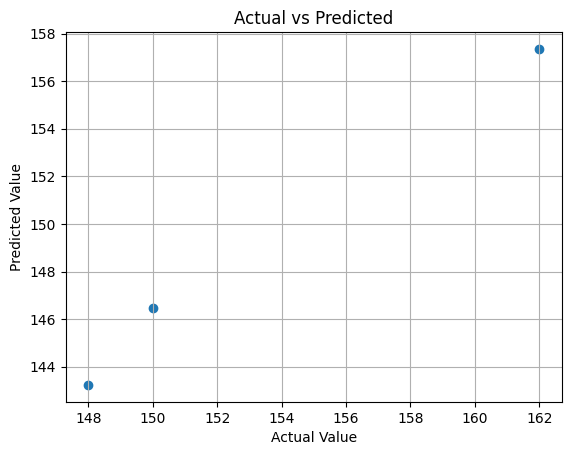

In [16]:
plt.scatter(y_test, predict_reg)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted")

plt.grid()
plt.show()

In [17]:
r2=r2_score(y_test,predict_reg)

In [18]:
r2

0.5065315932446277